# Clusterização dos Áudios, Geração dos Formulários e Classificação das Transcrições

Esse código tem como objetivo avaliar as transcrições como "boas" ou "ruins" através das métricas.

O processo de clusterização divide os áudios em grupos com características semelhantes. De maneira estratificada, alguns áudios foram selecionados para serem classificados manualmente, através de formulários.

Para classificar os áudios restantes, utilizamos a árvore de decisão ID3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

Dataframe com as métricas para todos os áudios

In [2]:
AUDIO_INFOS_DIR = "../data/qualidade_audios.csv"

df = pd.read_csv(AUDIO_INFOS_DIR)

df['silencio/tempo'] = df['regioes_silencio'] / df['duracao_segundos']
df['arquivo'] = df['arquivo'].apply(lambda nome_arquivo: Path(nome_arquivo).stem)

display(df)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
0,-89_5bDU5ko,54.566896,48000,0.087395,0.848866,0.102955,28.500414,0.068936,3,0.054978
1,LPDJollYuAc,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0,0.000000
2,zu1dIUoGd1g,706.880000,48000,0.044159,0.544028,0.081170,31.315220,0.075895,19,0.026879
3,0DQ82ua1GqQ,53.487167,48000,0.103145,0.984857,0.104731,37.229790,0.035058,0,0.000000
4,q2LIyyDKeOU,60.000979,48000,0.131033,1.044674,0.125430,51.049328,0.042408,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
8968,AN4cFw5rBBU,37.848979,48000,0.061322,0.792349,0.077393,26.758072,0.031574,4,0.105683
8969,pUfLK1jrglg,85.844188,48000,0.030217,0.389398,0.077599,34.001556,0.018390,1,0.011649
8970,63lBbV42njg,45.708500,48000,0.104041,1.014510,0.102553,27.954025,0.061560,0,0.000000
8971,1jOpENTEC4A,4715.067229,48000,0.048428,0.990683,0.048883,32.209175,0.040369,861,0.182606


In [4]:
# Para verificar se há *qualquer* valor nulo no DataFrame inteiro:
print("\nExiste algum valor nulo no DataFrame inteiro?")
print(df.isnull().any().any())

# Para ver as linhas que contêm valores nulos:
print("\nLinhas do DataFrame com valores nulos:")
print(df[df.isnull().any(axis=1)])
print(f'{len(df[df.isnull().any(axis=1)])} linhas com valores nulos.')


Existe algum valor nulo no DataFrame inteiro?
True

Linhas do DataFrame com valores nulos:
          arquivo  duracao_segundos  frequencia_amostragem  amplitude_media  \
688   WaFwAZxZ6bA          4.806542                  48000              0.0   
1381  vRQhKzPv_10          6.083646                  48000              0.0   
1433  K8y18trlUP8         30.011792                  48000              0.0   
1807  AM_pP8L0Cag          6.013979                  48000              0.0   
2196  r1hS_CGQF_w          2.020146                  48000              0.0   
3057  NeU6-Ps974k         52.709313                  48000              0.0   
3333  WQ9kdjBxq7Y         60.000979                  48000              0.0   
3367  tq4udeCZ-sw         11.006271                  48000              0.0   
3587  HgJpsG0J9iQ         15.000979                  48000              0.0   
3646  gp0-lg_kpMM          6.083646                  48000              0.0   
5800  uBPANTHe1CU        143.360000    

Linhas com valores nulos

In [5]:
df_temp = df.copy()
df_temp.replace([np.inf,-np.inf],np.nan,inplace=True)

metricas = ['duracao_segundos', 'frequencia_amostragem', 'amplitude_media','amplitude_maxima','amplitude_ratio (mean/max)','snr_estimado_db','zero_crossing_rate','silencio/tempo']  # substitua pelas suas métricas

# Pega as linhas que tiverem valores nulos
linhas_com_problema = df_temp[df_temp[metricas].isnull().any(axis=1)]
display(linhas_com_problema)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
688,WaFwAZxZ6bA,4.806542,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1381,vRQhKzPv_10,6.083646,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1433,K8y18trlUP8,30.011792,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1807,AM_pP8L0Cag,6.013979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
2196,r1hS_CGQF_w,2.020146,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3057,NeU6-Ps974k,52.709313,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3333,WQ9kdjBxq7Y,60.000979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3367,tq4udeCZ-sw,11.006271,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3587,HgJpsG0J9iQ,15.000979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3646,gp0-lg_kpMM,6.083646,48000,0.0,0.0,NaN,NaN,0.0,0,0.0


Remoção dessas linhas com valores nulos

In [6]:
filtro = df['arquivo'].isin(linhas_com_problema['arquivo'])
df_limpo = df[~filtro].copy()
display(df_limpo)

print(f"Linhas removidas: {len(df) - len(df_limpo)}")

# Para verificar se há *qualquer* valor nulo no DataFrame inteiro:
print("\nExiste algum valor nulo no DataFrame inteiro?")
print(df_limpo.isnull().any().any())

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
0,-89_5bDU5ko,54.566896,48000,0.087395,0.848866,0.102955,28.500414,0.068936,3,0.054978
1,LPDJollYuAc,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0,0.000000
2,zu1dIUoGd1g,706.880000,48000,0.044159,0.544028,0.081170,31.315220,0.075895,19,0.026879
3,0DQ82ua1GqQ,53.487167,48000,0.103145,0.984857,0.104731,37.229790,0.035058,0,0.000000
4,q2LIyyDKeOU,60.000979,48000,0.131033,1.044674,0.125430,51.049328,0.042408,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
8968,AN4cFw5rBBU,37.848979,48000,0.061322,0.792349,0.077393,26.758072,0.031574,4,0.105683
8969,pUfLK1jrglg,85.844188,48000,0.030217,0.389398,0.077599,34.001556,0.018390,1,0.011649
8970,63lBbV42njg,45.708500,48000,0.104041,1.014510,0.102553,27.954025,0.061560,0,0.000000
8971,1jOpENTEC4A,4715.067229,48000,0.048428,0.990683,0.048883,32.209175,0.040369,861,0.182606


Linhas removidas: 21

Existe algum valor nulo no DataFrame inteiro?
False


## Processo de Clusterização dos Áudios

Definição do número de clusters através do índice BetaCV e o método do cotovelo

Melhor valor de K encontrado pela 2ª derivada: K = 80
Primeira Derivada: [-0.08317714 -0.06534607 -0.03819363 -0.02159026 -0.01947253 -0.01993092
 -0.01419778 -0.01192663 -0.00988774 -0.00635    -0.00505754 -0.00667594
 -0.00594307 -0.00527964 -0.00445171 -0.00471125 -0.00583707 -0.00448784
 -0.00264789 -0.00195795]
Segunda Derivada: [ 0.01783107  0.02249176  0.0218779   0.00936055  0.00082967  0.00263738
  0.00400215  0.00215502  0.00278831  0.0024151  -0.00016297 -0.00044277
  0.00069815  0.00074568  0.0002842  -0.00069268  0.00011171  0.00159459
  0.00126494  0.00068994]


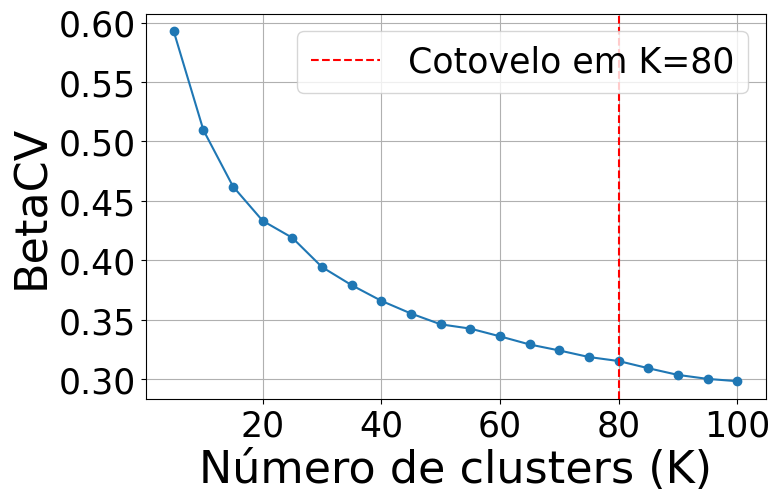

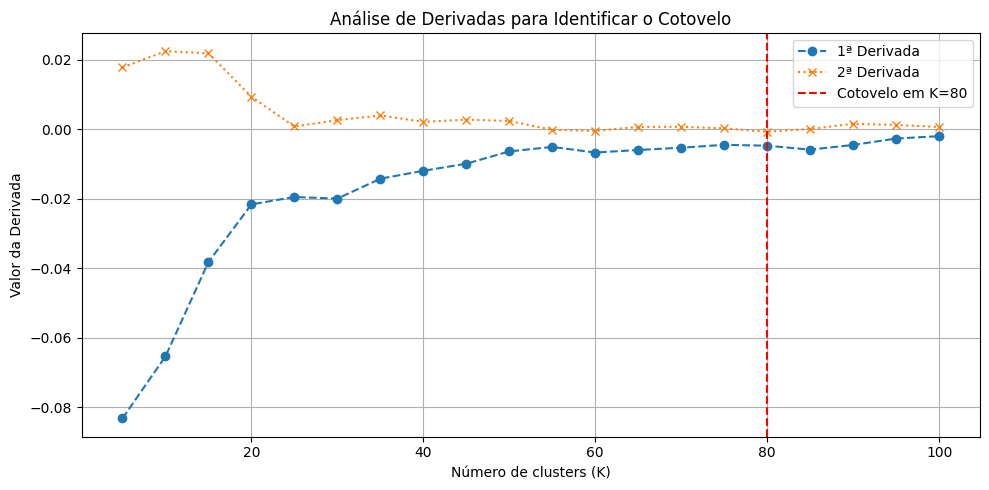

In [7]:
# Definição da função BetaCV (avalia a qualidade de um agrupamento; quanto menor, melhor)
def beta_cv(X, labels):
    distances = pairwise_distances(X) # DIstancia entre todos os pontos
    n = len(labels) # Número de amostras 
    
    # Soma das distâncias dentro de um cluster
    def intra_cluster_distance(dist_row, labels, idx):
        same_cluster = labels == labels[idx]
        same_cluster[idx] = False
        return np.sum(dist_row[same_cluster])

    # Soma das distâncias para pontos em outro cluster
    def inter_cluster_distance(dist_row, labels, idx):
        other_cluster = labels != labels[idx]
        return np.sum(dist_row[other_cluster])

    # Calcula as somas intra e inter para cada ponto
    A = np.array([intra_cluster_distance(distances[i], labels, i) for i in range(n)])
    B = np.array([inter_cluster_distance(distances[i], labels, i) for i in range(n)])

    a = np.sum(A) # Soma total intra-cluster
    b = np.sum(B) # Soma total inter-cluster

    # Conta os membros de cada cluster
    labels_unq = np.unique(labels)
    members = np.array([(labels == lbl).sum() for lbl in labels_unq])

    # Número total de pares intra-cluster possíveis
    N_in = np.array([m * (m - 1) for m in members])
    n_in = np.sum(N_in)

    # Número total de pares inter-cluster possíveis
    N_out = np.array([m * (n - m) for m in members])
    n_out = np.sum(N_out)

    # Cálculo do índice BetaCV
    beta_cv_value = (a / n_in) / (b / n_out)

    return beta_cv_value


metricas = ['duracao_segundos', 'frequencia_amostragem', 'amplitude_media','amplitude_maxima','amplitude_ratio (mean/max)','snr_estimado_db','zero_crossing_rate','silencio/tempo'] 
data = df_limpo[metricas].values

# 1. Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# 2. Rodar KMeans para vários valores de K e calcular BetaCV
k_values = range(5, 101, 5)
betacv_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = beta_cv(X_scaled, labels)
    betacv_scores.append(score)

# Derivadas numéricas (usando diferenças finitas)
first_derivative = np.gradient(betacv_scores)
second_derivative = np.gradient(first_derivative)

# O ponto de cotovelo pode ser aquele com maior curvatura (mínimo da segunda derivada)
knee_index = np.argmin(second_derivative)
melhor_k = k_values[knee_index]

print(f"Melhor valor de K encontrado pela 2ª derivada: K = {melhor_k}")
print(f"Primeira Derivada: {first_derivative}")
print(f"Segunda Derivada: {second_derivative}")

# PLot do Método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(k_values, betacv_scores, marker='o')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.xlabel('Número de clusters (K)', fontsize=32)
plt.ylabel('BetaCV', fontsize=32)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)
plt.show()

# --- Plot 2: Derivadas ---
plt.figure(figsize=(10, 5))
plt.plot(k_values, first_derivative, label='1ª Derivada', marker='o', linestyle='--')
plt.plot(k_values, second_derivative, label='2ª Derivada', marker='x', linestyle=':')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.title('Análise de Derivadas para Identificar o Cotovelo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Valor da Derivada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Clusterização: visualização com PCA

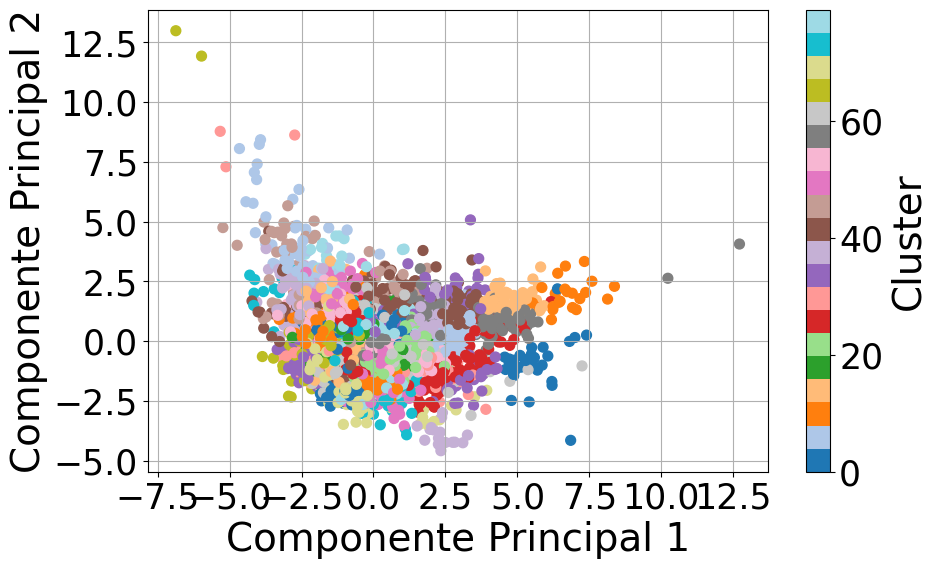

Cluster 0: 153 pontos
Cluster 1: 376 pontos
Cluster 2: 169 pontos
Cluster 3: 30 pontos
Cluster 4: 178 pontos
Cluster 5: 14 pontos
Cluster 6: 23 pontos
Cluster 7: 62 pontos
Cluster 8: 93 pontos
Cluster 9: 145 pontos
Cluster 10: 23 pontos
Cluster 11: 119 pontos
Cluster 12: 308 pontos
Cluster 13: 89 pontos
Cluster 14: 117 pontos
Cluster 15: 65 pontos
Cluster 16: 113 pontos
Cluster 17: 224 pontos
Cluster 18: 121 pontos
Cluster 19: 144 pontos
Cluster 20: 249 pontos
Cluster 21: 132 pontos
Cluster 22: 259 pontos
Cluster 23: 34 pontos
Cluster 24: 325 pontos
Cluster 25: 217 pontos
Cluster 26: 68 pontos
Cluster 27: 41 pontos
Cluster 28: 74 pontos
Cluster 29: 3 pontos
Cluster 30: 89 pontos
Cluster 31: 40 pontos
Cluster 32: 33 pontos
Cluster 33: 32 pontos
Cluster 34: 91 pontos
Cluster 35: 106 pontos
Cluster 36: 250 pontos
Cluster 37: 17 pontos
Cluster 38: 55 pontos
Cluster 39: 58 pontos
Cluster 40: 36 pontos
Cluster 41: 163 pontos
Cluster 42: 253 pontos
Cluster 43: 64 pontos
Cluster 44: 23 pontos


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Defina o número de clusters
#k = 20 # ou use melhor_k, se tiver definido anteriormente


# 2. Aplique KMeans com o K escolhido
kmeans = KMeans(n_clusters=melhor_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 3. Reduza para 2 dimensões usando PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plote os clusters em 2D
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=50)
plt.xlabel('Componente Principal 1', fontsize=28)
plt.ylabel('Componente Principal 2', fontsize=28)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster', fontsize=28)
cbar.ax.tick_params(labelsize=25)    
plt.grid(True)
plt.show()

# labels contém o cluster atribuído a cada ponto
counts = np.bincount(labels)
df_limpo["cluster"] = labels

# Printar o número de pontos em cada cluster
for cluster_id, count in enumerate(counts):
    print(f"Cluster {cluster_id}: {count} pontos")


Amostragem estratificada: obtendo 100 áudios para classificação manual

In [39]:
import math

# Geração automática do dicionário
cluster_data = {f"{cluster_id}": count for cluster_id, count in enumerate(counts)}

# Converte os dados para um DataFrame pandas
df_clusters = pd.DataFrame(list(cluster_data.items()), columns=['Cluster', 'Points'])

# Calcula o total de pontos
total_points = df_clusters['Points'].sum()

# Define o tamanho da amostra desejada
sample_size = 326
# Calcula a proporção para cada cluster e o número de áudios a serem amostrados de cada um
df_clusters['Proportion'] = df_clusters['Points'] / total_points
df_clusters['Sampled_Audios_Raw'] = df_clusters['Proportion'] * sample_size
df_clusters['Sampled_Audios'] = df_clusters['Sampled_Audios_Raw'].round().astype(int)

# Ajusta os erros de arredondamento para garantir que a soma seja exatamente 100
current_sum = df_clusters['Sampled_Audios'].sum()
difference = sample_size - current_sum

if difference != 0:
    df_clusters['Fractional_Part'] = df_clusters['Sampled_Audios_Raw'] - df_clusters['Sampled_Audios']
    if difference > 0:
        # Adiciona aos clusters com as maiores partes fracionárias
        clusters_to_adjust = df_clusters.nlargest(difference, 'Fractional_Part')
        df_clusters.loc[clusters_to_adjust.index, 'Sampled_Audios'] += 1
    else:
        # Subtrai dos clusters com as menores (mais negativas) partes fracionárias
        clusters_to_adjust = df_clusters.nsmallest(abs(difference), 'Fractional_Part')
        df_clusters.loc[clusters_to_adjust.index, 'Sampled_Audios'] -= 1

# Exibe o resultado
print("Amostragem estratificada por cluster:")
print(f"\nTotal de áudios amostrados: {df_clusters['Sampled_Audios'].sum()}")

display(df_clusters)


Amostragem estratificada por cluster:

Total de áudios amostrados: 326


,Cluster,Points,Proportion,Sampled_Audios_Raw,Sampled_Audios,Fractional_Part
0,0,153,0.017091,5.571716,6,-0.428284
1,1,376,0.042002,13.692583,14,-0.307417
2,2,169,0.018878,6.154379,6,0.154379
3,3,30,0.003351,1.092493,1,0.092493
4,4,178,0.019884,6.482127,7,0.482127
...,...,...,...,...,...,...
75,75,134,0.014969,4.879803,5,-0.120197
76,76,181,0.020219,6.591376,7,-0.408624
77,77,204,0.022788,7.428954,7,0.428954
78,78,62,0.006926,2.257819,2,0.257819


In [74]:
amostras = {}
clusters_com_poucos_videos = []

for i in range(len(df_clusters)):
    tam_amostra = int(df_clusters["Sampled_Audios"].iloc[i])
    
    aux = df_limpo[(df_limpo['cluster'] == i) & (df_limpo['duracao_segundos'] <= 120)]
    qtd_disponivel = len(aux)

    if tam_amostra > 0 and qtd_disponivel > 0:
        amostra_i = aux.sample(n=min(tam_amostra, qtd_disponivel), random_state=42)
        amostras[i] = amostra_i['arquivo'].to_list()
        
        if qtd_disponivel < tam_amostra:
            clusters_com_poucos_videos.append((i, qtd_disponivel, tam_amostra))
    elif tam_amostra > 0:
        # Nenhum vídeo disponível com duração < 120 seg nesse cluster
        clusters_com_poucos_videos.append((i, 0, tam_amostra))

# Exibir clusters que não conseguiram a quantidade desejada
if clusters_com_poucos_videos:
    print("Clusters com vídeos insuficientes:")
    for cluster_id, qtd_encontrada, qtd_esperada in clusters_com_poucos_videos:
        print(f"Cluster {cluster_id}: {qtd_encontrada} disponíveis, {qtd_esperada} esperados")
else:
    print("Todos os clusters têm vídeos suficientes.")

count = 0
for i, id in amostras.items():
    for j in id:
        count += 1

print(count)


Clusters com vídeos insuficientes:
Cluster 5: 0 disponíveis, 1 esperados
Cluster 6: 0 disponíveis, 1 esperados
Cluster 7: 0 disponíveis, 2 esperados
Cluster 13: 0 disponíveis, 3 esperados
Cluster 38: 0 disponíveis, 2 esperados
Cluster 39: 0 disponíveis, 2 esperados
Cluster 44: 0 disponíveis, 1 esperados
Cluster 45: 0 disponíveis, 2 esperados
Cluster 47: 0 disponíveis, 1 esperados
Cluster 49: 0 disponíveis, 3 esperados
Cluster 71: 0 disponíveis, 2 esperados
Cluster 75: 0 disponíveis, 5 esperados
Cluster 79: 0 disponíveis, 1 esperados
300


Ids dos vídeos e suas transcrições

In [75]:
import os
import pandas as pd

transcriptions_folder = '/Users/voamorim/Documents/UFSJ/6o_periodo/MineracaoDeDadosAplicada/LeiFelca/LeiFelca/transcriptions' 

data = []

for file in os.listdir(transcriptions_folder): # retorna uma lista com os nomes de tudo que esta dentro de transcriptions_folder
    if os.path.isfile(os.path.join(transcriptions_folder,file)): # verifica se o caminho aponta para um arquivo existente
        file_path = os.path.join(transcriptions_folder,file) # caminho de cada file
        try:
            with open(file_path,'r') as f:
                text = f.read()
                id = file.replace('.txt','')
                data.append({'id': id, 'text': text}) # guarda o id do vídeo e a transcrição nele presente
        except Exception as e:
            print(f"Erro ao ler o arquivo {file}: {e}")

df_transcricoes = pd.DataFrame(data)
display(df_transcricoes)

,id,text
0,hFH8DPa-zf0,E... Tem pelo cara casa E calaí pra canto Na ...
1,kbFLzsENOFU,"Para ela, será que quero lamber? Não, não que..."
2,6s3lGq5oVpY,"Eu já observei. Pessoa que tem depressão, às ..."
3,ZRRx6GFVLQ0,"Olá comunidade Roblox. Leifelkin Vigor, lootb..."
4,3T3jrTUQqgU,desanimadora sabe cara porque era uma lei que...
...,...,...
8968,mgGl-R1G06c,"Muito boa noite, com muita alegria que nós co..."
8969,AmtTZJ6ohAI,"que a internet parou com o vídeo do Felca, is..."
8970,6rRr4OH8P_I,Não é à toa que o baile de Halloween da sefor...
8971,7Hc685014FU,"O Felca é uma pessoa muito querida por nós, i..."


Gerando imagens das transcrições para os formulários

In [76]:
#!pip install imgkit Pillow
 
from html2image import Html2Image 
from pathlib import Path
from mutagen.oggopus import OggOpus
from moviepy import ImageClip
import os
import imgkit
from PIL import Image 

def create_html_with_text(text):
    html_content = '''
        <!DOCTYPE html>
        <html lang="en">
        <head>
            <meta charset="UTF-8">
            <meta name="viewport" content="width=device-width, initial-scale=1.0">
            <title>Retângulo de Texto</title>
            <style>
                body {{
                    font-family: Arial, sans-serif;
                    margin: 0;
                    padding: 0;
                    background-color: transparent; 
                }}
                .wrapper {{
                    background-color: #ffffff;
                    padding: 15px;
                    display: inline-block;
                }}
                .dialog-bubble {{
                    background: lightblue;
                    border-radius: 10px;
                    padding: 25px 40px;
                    display: inline-block; 
                    max-width: 600px; 
                    color: #333;
                    font-size: 20px;
                    box-shadow: 0 4px 15px rgba(0,0,0,0.1);
                    text-align: center;
                    line-height: 1.4;
                    box-sizing: border-box;
                }}
            </style>
        </head>
        <body>
            <!-- O wrapper abriga o balão e cria a margem branca ao redor dele -->
            <div class="wrapper">
                <div class="dialog-bubble">
                    {}
                </div>
            </div>
        </body>
        </html>
    '''.format(text)

    return html_content

def use(text, savefile):
    html_content = create_html_with_text(text)

    # Criação do diretório
    output_dir = Path("../images_transcriptions")
    output_dir.mkdir(parents=True, exist_ok=True)

    html_path = output_dir / f"{savefile}.html"
    html_path.write_text(html_content, encoding="utf-8")

    image_path = output_dir / f"{savefile}.png"

    options = {
        'format': 'png',
        'transparent': '', 
        'quality': '100',
        'encoding': "UTF-8",
        'enable-local-file-access': None,
    }

    imgkit.from_file(str(html_path), str(image_path), options=options)
    
    img = Image.open(image_path).convert("RGBA")
    bbox = img.getbbox() 
    
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(image_path)
    
    if html_path.exists():
        html_path.unlink()
        
    print("Imagem gerada e recortada no tamanho exato com sucesso!")

In [77]:
TRANCRICOES_DIR = "../transcriptions"
df_transcricoes.set_index('id', inplace=True)

In [73]:

erro = 0
for cluster,arquivo in amostras.items():
    for id in arquivo:
        try:
            text = df_transcricoes.loc[id,'text']
            use(text,id)
        except Exception as e:
            print(f"Ocorreu um erro ao processar o arquivo '{id}': {e}")
            erro += 1
print(erro)


Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Imagem gerada e recortada no tamanho exato com sucesso!
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Imagem gerada e recortada no tamanho exato com sucesso!
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Imagem gerada e recortada no tamanho exato com sucesso!
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Imagem gerada e recortada no tamanho exato com sucesso!
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
I

In [34]:
id_amostras = []
for cluster,arquivo in amostras.items():
    for id in arquivo:
        id_amostras.append(id)
display(df_limpo[df_limpo['arquivo'].isin(id_amostras)])


,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo,cluster
1,LPDJollYuAc,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0,0.000000,57
9,QinBWzZ3txo,102.720000,48000,0.028180,0.244930,0.115052,28.452297,0.074188,4,0.038941,14
15,0kKGkXgTxk0,63.204729,48000,0.050613,0.274218,0.184573,58.524460,0.047456,0,0.000000,50
27,4McSTEYaK5I,85.333333,48000,0.086931,0.755569,0.115053,30.002660,0.090708,2,0.023438,16
31,AwTPrxLK4yk,68.115750,48000,0.071244,0.947728,0.075173,31.164986,0.050850,18,0.264256,2
...,...,...,...,...,...,...,...,...,...,...,...
8826,VoyUZjYWuHY,70.170708,48000,0.037593,0.675189,0.055678,22.093180,0.024142,0,0.000000,48
8827,SXYRkjxVcPU,36.269583,48000,0.104774,0.888413,0.117934,27.808058,0.046220,1,0.027571,1
8852,5T0NJcZoa_0,81.618146,48000,0.034179,0.593624,0.057577,28.953167,0.066192,17,0.208287,68
8857,27TMnxN4FAQ,58.769708,48000,0.066620,1.011562,0.065859,20.716448,0.045147,0,0.000000,53


Links para vídeos de cada formulário

In [35]:
def link_video(video_id):
    url = f"https://www.youtube.com/watch?v={video_id}"
    print(url)

count = 10
i = 0
for id in id_amostras:
    if(count == 10):
        i += 1
        print(f"Formulário {i}")
        count = 0
    count += 1
    link_video(id)

Formulário 1
https://www.youtube.com/watch?v=9EUEoBBKsDw
https://www.youtube.com/watch?v=UYzkLh7ogbg
https://www.youtube.com/watch?v=BZr_tywUSEA
https://www.youtube.com/watch?v=uoQ7FF2cmYo
https://www.youtube.com/watch?v=lw5GHQ7n06U
https://www.youtube.com/watch?v=dE2W3E6vuEY
https://www.youtube.com/watch?v=35NMXfx-j08
https://www.youtube.com/watch?v=SXYRkjxVcPU
https://www.youtube.com/watch?v=dVC9Lt8AkZU
https://www.youtube.com/watch?v=ShVmMUPaBo8
Formulário 2
https://www.youtube.com/watch?v=1jzcNWLaZZ4
https://www.youtube.com/watch?v=DB1qZ9LTtac
https://www.youtube.com/watch?v=f7U-ZQ4dRRA
https://www.youtube.com/watch?v=K_pIJh3-cR4
https://www.youtube.com/watch?v=Sri-a3m5GRo
https://www.youtube.com/watch?v=A6LE8YrwaAw
https://www.youtube.com/watch?v=7U1B5obs0iY
https://www.youtube.com/watch?v=DkxamO1daSE
https://www.youtube.com/watch?v=B5qYxZrMeC0
https://www.youtube.com/watch?v=vRLvD8TbR4M
Formulário 3
https://www.youtube.com/watch?v=4v2xgIkhBQM
https://www.youtube.com/watch?v=AwTPr

# Até aqui por enquanto

---

Reunindo as respostas dos formulários - cada transcrição recebeu 3 classificações

In [63]:
# Reunindo as respostas dos formulários

DIR = "../../filtrated_data_log/"
AUDIO_RESPOSTAS_DIR = [f"{DIR}respostas_formularios/1.csv",f"{DIR}respostas_formularios/2.csv",f"{DIR}respostas_formularios/3.csv",f"{DIR}respostas_formularios/4.csv",f"{DIR}respostas_formularios/5.csv",f"{DIR}respostas_formularios/6.csv",f"{DIR}respostas_formularios/7.csv",f"{DIR}respostas_formularios/8.csv",f"{DIR}respostas_formularios/9.csv",f"{DIR}respostas_formularios/10.csv"]
df_classificacao = df_limpo[df_limpo['arquivo'].isin(id_amostras)].copy()

i=0
for DIR in AUDIO_RESPOSTAS_DIR:
    df_resposta = pd.read_csv(DIR)
    df_resposta = df_resposta.drop(columns=['Carimbo de data/hora', 'Nome Completo:', 'Email:'])
    remove = "https://www.youtube.com/watch?v="
    df_resposta.columns = df_resposta.columns.str.replace(remove,'', regex=False).str.strip()


    for id in df_resposta.columns:
        respostas = df_resposta[id]
        if id in df_classificacao['arquivo'].values:
            try:
                df_classificacao.loc[df_classificacao['arquivo'] == id, 'resposta_1'] = respostas[0]
                df_classificacao.loc[df_classificacao['arquivo'] == id, 'resposta_2'] = respostas[1]
                df_classificacao.loc[df_classificacao['arquivo'] == id, 'resposta_3'] = respostas[2]
            except IndexError:
                print(f"Erro em ID '{id}' no arquivo '{DIR}'.")
        else:
            print(f"Aviso: ID '{id}' do arquivo '{DIR}' não encontrado.")
display(df_classificacao)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo,cluster,resposta_1,resposta_2,resposta_3
5,hEPS5wpurkM,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,0.000000,26,RUIM,RUIM,RUIM
10,qUn3HMVoKA8,37.755667,48000,0.000706,0.023461,0.030086,24.760537,0.117910,15,0.397291,8,RUIM,RUIM,BOA
14,RTekEjC4Nps,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,0.000000,13,RUIM,RUIM,BOA
35,01MmDF37yfQ,10.794667,48000,0.032956,0.354776,0.092892,103.541698,0.046396,1,0.092638,15,BOA,BOA,BOA
48,rtmes3DnU08,55.402813,48000,0.049803,0.491308,0.101368,31.442895,0.031728,12,0.216596,1,BOA,BOA,BOA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,IgAX2guU868,49.168271,48000,0.047448,0.735171,0.064540,24.861004,0.037497,0,0.000000,7,BOA,BOA,BOA
1820,bGD5J3O5qtA,30.139521,48000,0.007509,1.027588,0.007307,15.385671,0.068764,18,0.597223,25,RUIM,RUIM,RUIM
1823,te-TPwCT90I,48.552979,48000,0.044997,0.540713,0.083217,27.045333,0.049216,13,0.267749,1,BOA,BOA,BOA
1837,soOctsiuUY4,59.884271,48000,0.156079,1.094333,0.142625,31.123767,0.065619,2,0.033398,20,BOA,BOA,BOA


Decidindo a classificação final de cada áudio da amostra

In [64]:
counts = {
    'boa_tres': 0,
    'boa_duas': 0,
    'ruim_tres': 0,
    'ruim_duas': 0
}

def adicionar_classificacao(row):
    respostas_linha = [row['resposta_1'],row['resposta_2'],row['resposta_3']]
    count_boa = respostas_linha.count('BOA')
    count_ruim = respostas_linha.count('RUIM')

    if count_boa == 3:
        counts['boa_tres'] += 1
    elif count_boa == 2:
        counts['boa_duas'] += 1
    elif count_ruim == 3:
        counts['ruim_tres'] += 1
    elif count_ruim == 2:
        counts['ruim_duas'] += 1

    if count_boa > count_ruim:
        return 'BOA'
    else:
        return 'RUIM'
df_classificacao['classificacao'] = df_classificacao.apply(adicionar_classificacao, axis=1)

display(df_classificacao)
print(counts)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo,cluster,resposta_1,resposta_2,resposta_3,classificacao
5,hEPS5wpurkM,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,0.000000,26,RUIM,RUIM,RUIM,RUIM
10,qUn3HMVoKA8,37.755667,48000,0.000706,0.023461,0.030086,24.760537,0.117910,15,0.397291,8,RUIM,RUIM,BOA,RUIM
14,RTekEjC4Nps,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,0.000000,13,RUIM,RUIM,BOA,RUIM
35,01MmDF37yfQ,10.794667,48000,0.032956,0.354776,0.092892,103.541698,0.046396,1,0.092638,15,BOA,BOA,BOA,BOA
48,rtmes3DnU08,55.402813,48000,0.049803,0.491308,0.101368,31.442895,0.031728,12,0.216596,1,BOA,BOA,BOA,BOA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,IgAX2guU868,49.168271,48000,0.047448,0.735171,0.064540,24.861004,0.037497,0,0.000000,7,BOA,BOA,BOA,BOA
1820,bGD5J3O5qtA,30.139521,48000,0.007509,1.027588,0.007307,15.385671,0.068764,18,0.597223,25,RUIM,RUIM,RUIM,RUIM
1823,te-TPwCT90I,48.552979,48000,0.044997,0.540713,0.083217,27.045333,0.049216,13,0.267749,1,BOA,BOA,BOA,BOA
1837,soOctsiuUY4,59.884271,48000,0.156079,1.094333,0.142625,31.123767,0.065619,2,0.033398,20,BOA,BOA,BOA,BOA


{'boa_tres': 48, 'boa_duas': 10, 'ruim_tres': 27, 'ruim_duas': 15}


In [65]:
X = df_classificacao[['duracao_segundos', 'frequencia_amostragem', 'amplitude_media', 'amplitude_maxima',
        'amplitude_ratio (mean/max)', 'snr_estimado_db', 'zero_crossing_rate', 
        'regioes_silencio', 'silencio/tempo']]
y = df_classificacao['classificacao']

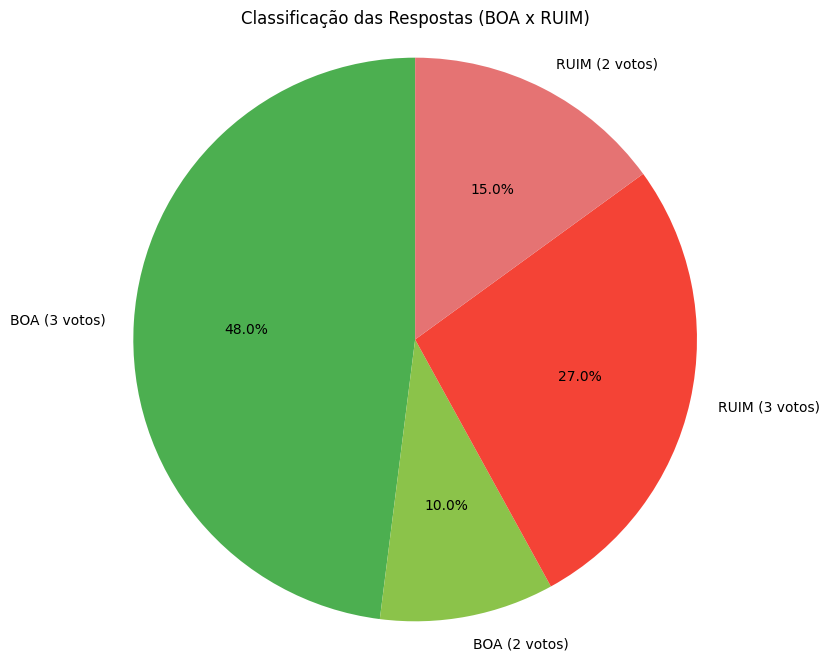

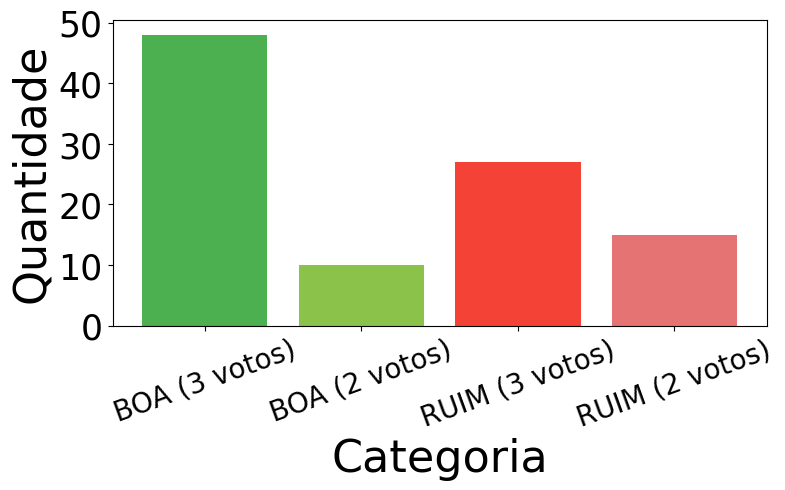

In [69]:
labels = ['BOA (3 votos)', 'BOA (2 votos)', 'RUIM (3 votos)', 'RUIM (2 votos)']
sizes = [counts['boa_tres'], counts['boa_duas'], counts['ruim_tres'], counts['ruim_duas']]
colors = ['#4CAF50', '#8BC34A', '#F44336', '#E57373']  # Verde para boas, vermelho para ruins

# Criando o gráfico
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Classificação das Respostas (BOA x RUIM)')
plt.axis('equal')  # Deixa o gráfico redondo

plt.show()

labels = ['BOA (3 votos)', 'BOA (2 votos)', 'RUIM (3 votos)', 'RUIM (2 votos)']
sizes = [counts['boa_tres'], counts['boa_duas'], counts['ruim_tres'], counts['ruim_duas']]
colors = ['#4CAF50', '#8BC34A', '#F44336', '#E57373']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, sizes, color=colors)

plt.xlabel('Categoria', fontsize=32)
plt.ylabel('Quantidade', fontsize=32)
plt.xticks(rotation=20, fontsize=20)
plt.yticks(fontsize=25)
plt.tight_layout()
plt.show()

## Classificação com Árvore de Decisao ID3

In [ ]:
le = LabelEncoder()
y_codificado = le.fit_transform(y)

f1_macro = make_scorer(f1_score, average='macro')
id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Encontra a melhor combinação de parâmetros da árvore de decisão id3

parametros = {
    'max_depth': [None, 5, 10, 15, 20, 30],  # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10, 20],    # Mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4, 6, 10],   # Mínimo de amostras por folha
    'max_features': [None, 'sqrt', 'log2'], # Máx de atributos a considerar por divisão
    'class_weight': [None, 'balanced'], # Peso das classes
    'splitter': ['best', 'random'] # Estratégia de divisão de cada nó
}

grid_search = GridSearchCV(
    estimator=id3,
    param_grid=parametros,
    scoring=f1_macro,
    cv=5, # Validação cruzada com 5 dobras
    n_jobs=-1  # usa todos os núcleos da CPU (opcional)
)

grid_search.fit(X, y_codificado)

# Resultados
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor macro F1:", grid_search.best_score_)

# Melhor modelo
best_model = grid_search.best_estimator_

resultados = pd.DataFrame(grid_search.cv_results_).sort_values(by='mean_test_score', ascending=False)
display(resultados)

Melhores parâmetros: {'class_weight': None, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'splitter': 'best'}
Melhor macro F1: 0.7777526863588244


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
516,0.003531,0.000025,0.005147,0.000013,None,20,None,10,10,best,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.800000,0.846547,0.791667,0.67033,0.780220,0.777753,0.058253,1
518,0.003944,0.000561,0.005106,0.000037,None,20,None,10,20,best,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.800000,0.846547,0.791667,0.67033,0.780220,0.777753,0.058253,1
512,0.003543,0.000013,0.005118,0.000013,None,20,None,10,2,best,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.800000,0.846547,0.791667,0.67033,0.780220,0.777753,0.058253,1
514,0.003540,0.000017,0.005063,0.000207,None,20,None,10,5,best,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.800000,0.846547,0.791667,0.67033,0.780220,0.777753,0.058253,1
34,0.003611,0.000023,0.005224,0.000025,None,None,None,10,5,best,"{'class_weight': None, 'max_depth': None, 'max...",0.800000,0.846547,0.791667,0.67033,0.780220,0.777753,0.058253,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,0.003234,0.000020,0.005049,0.000012,None,20,sqrt,10,5,random,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.354839,0.670330,0.500000,0.37500,0.626667,0.505367,0.127757,1393
477,0.003309,0.000005,0.005094,0.000018,None,15,log2,10,10,random,"{'class_weight': None, 'max_depth': 15, 'max_f...",0.354839,0.670330,0.500000,0.37500,0.626667,0.505367,0.127757,1393
557,0.003296,0.000044,0.005673,0.001077,None,20,sqrt,10,10,random,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.354839,0.670330,0.500000,0.37500,0.626667,0.505367,0.127757,1393
479,0.003305,0.000020,0.005096,0.000071,None,15,log2,10,20,random,"{'class_weight': None, 'max_depth': 15, 'max_f...",0.354839,0.670330,0.500000,0.37500,0.626667,0.505367,0.127757,1393


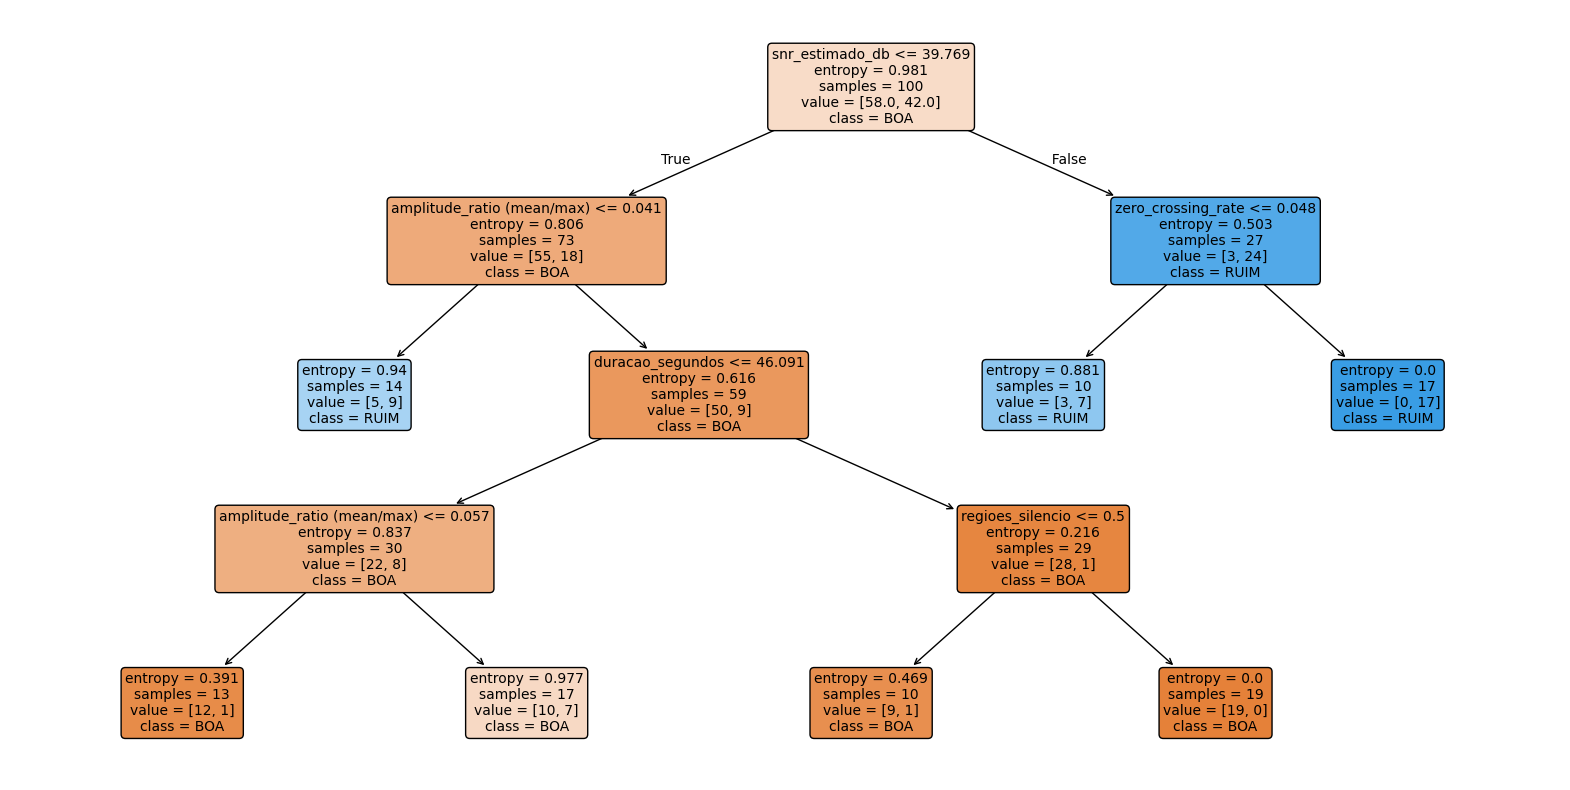

In [ ]:
plt.figure(figsize=(20, 10)) 
plot_tree(
    best_model, 
    feature_names=X.columns,  
    class_names=le.classes_,  
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.show()

In [ ]:
arvore_texto = export_text(
    best_model,
    feature_names=list(X.columns)
)
print(arvore_texto)

|--- snr_estimado_db <= 39.77
|   |--- amplitude_ratio (mean/max) <= 0.04
|   |   |--- class: 1
|   |--- amplitude_ratio (mean/max) >  0.04
|   |   |--- duracao_segundos <= 46.09
|   |   |   |--- amplitude_ratio (mean/max) <= 0.06
|   |   |   |   |--- class: 0
|   |   |   |--- amplitude_ratio (mean/max) >  0.06
|   |   |   |   |--- class: 0
|   |   |--- duracao_segundos >  46.09
|   |   |   |--- regioes_silencio <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- regioes_silencio >  0.50
|   |   |   |   |--- class: 0
|--- snr_estimado_db >  39.77
|   |--- zero_crossing_rate <= 0.05
|   |   |--- class: 1
|   |--- zero_crossing_rate >  0.05
|   |   |--- class: 1



In [ ]:
# Separando os dados rotulados e não rotulados
df_treino = df_classificacao.copy()
df_teste = df_limpo[~df_limpo['arquivo'].isin(df_treino['arquivo'])].copy()

colunas_entrada = ['duracao_segundos', 'frequencia_amostragem', 'amplitude_media', 'amplitude_maxima',
                   'amplitude_ratio (mean/max)', 'snr_estimado_db', 'zero_crossing_rate',
                   'regioes_silencio', 'silencio/tempo']

X_train = df_treino[colunas_entrada]
y_train = df_treino['classificacao']

le = LabelEncoder()
y_train_cod = le.fit_transform(y_train)

# Treinando o modelo com os melhores hiperparâmetros
modelo_final = DecisionTreeClassifier(
    class_weight=None,
    max_depth=None,
    max_features=None,
    min_samples_leaf=10,
    min_samples_split=2,
    splitter='best',
    criterion='entropy',
    random_state=42
)

modelo_final.fit(X_train, y_train_cod)

# Previsões no restante dos áudios (df_teste)
X_test = df_teste[colunas_entrada]
y_pred = modelo_final.predict(X_test)
y_predito = le.inverse_transform(y_pred)

df_teste['classificacao_prevista'] = y_predito
display(df_teste)


,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo,cluster,classificacao_prevista
0,myPV9PdsX04,348.786958,48000,0.026415,1.042867,0.025329,28.842549,0.039911,47,0.134753,10,RUIM
1,q_SI-rVN6iw,410.110854,48000,0.029762,0.927915,0.032074,35.811853,0.034090,92,0.224330,10,RUIM
2,0Pg4eX2Fo6g,388.928000,48000,0.040820,0.706327,0.057792,28.362591,0.032910,176,0.452526,19,BOA
3,5plz1EPg10c,275.110042,48000,0.206517,1.280014,0.161340,43.374400,0.063981,77,0.279888,20,RUIM
4,P_iY5VFrozk,338.872021,48000,0.021286,0.947819,0.022458,29.139154,0.034929,73,0.215421,10,RUIM
...,...,...,...,...,...,...,...,...,...,...,...,...
1952,kN3p6HIfW3Y,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,0.000000,24,RUIM
1953,zfKxM-uFgho,632.209708,48000,0.057196,0.989910,0.057779,26.054435,0.061720,3,0.004745,23,BOA
1954,Mo5ybNOwS80,456.980333,48000,0.033653,1.083810,0.031051,31.381006,0.040483,134,0.293229,2,RUIM
1955,msLGDdIQUkw,165.442187,48000,0.026978,0.537679,0.050175,23.677936,0.047942,29,0.175288,1,BOA


In [ ]:
df_teste['classificacao_prevista'].value_counts()

classificacao_prevista
BOA     1010
RUIM     820
Name: count, dtype: int64

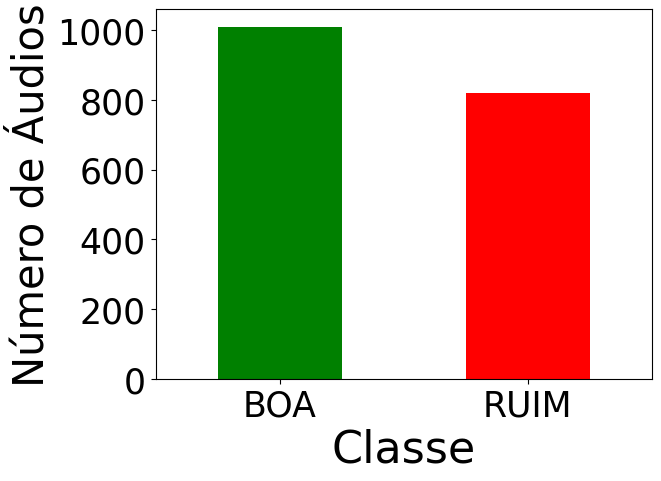

In [71]:
df_teste['classificacao_prevista'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xlabel('Classe', fontsize=32)
plt.ylabel('Número de Áudios', fontsize=30)
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)
plt.show()

In [ ]:
#Guardando as transcrições boas em um csv
ids_boas_transcricoes_prev = df_teste[df_teste['classificacao_prevista']=='BOA']['arquivo']
ids_boas_transcricoes_forms = df_classificacao[df_classificacao['classificacao']=='BOA']['arquivo']

ids_boas_transcricoes = pd.concat([ids_boas_transcricoes_prev, ids_boas_transcricoes_forms], ignore_index=True)
ids_boas_transcricoes.to_csv("../../filtrated_data_log/ids_transcricoes_boas.csv", index = False)